# 03 - Model Evaluation Report (Artifact-Driven)

**PhishGuard URL - EATC Assignment 2 - 2026**

This notebook is deliberately **reporting-only**. It does not load the raw dataset, fit a model, select a model, or generate test predictions. The complete training and one-time final test evaluation must be performed first with:

```powershell
python scripts/train_models.py --data data/Dataset.csv
```

The notebook then reads the saved CSV and JSON artifacts to present the modelling and evaluation evidence.

## Evaluation workflow

1. `train_models.py` cleans the data and creates domain-exclusive train, validation, and test splits.
2. Five candidates are compared using validation phishing F1.
3. The winner is refitted on train plus validation data.
4. The refitted model is evaluated once on the domain-unseen test set.
5. This notebook reads the resulting artifacts without repeating any modelling operation.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "app").is_dir():
    if (ROOT.parent / "app").is_dir():
        ROOT = ROOT.parent
    else:
        raise RuntimeError(
            "Start Jupyter from the repository root or the notebooks folder."
        )

MODELS_DIR = ROOT / "models"
REPORTS_DIR = ROOT / "reports"
sns.set_theme(style="darkgrid")

print(f"Repository root: {ROOT}")
print("Reporting-only notebook ready. No model-training modules were imported.")

Repository root: C:\Users\Lenovo\Downloads\PHISHGUARD_URL
Reporting-only notebook ready. No model-training modules were imported.


## 1. Validate the official training artifacts

A missing file means the official training pipeline has not completed. Run the command shown in the first cell before continuing.

In [2]:
ARTIFACTS = {
    "evaluation metadata": MODELS_DIR / "best_model_evaluation.json",
    "model comparison": REPORTS_DIR / "validation_comparison.csv",
    "final test metrics": REPORTS_DIR / "final_test_metrics.csv",
    "feature importance": REPORTS_DIR / "permutation_importance.csv",
    "test curves": REPORTS_DIR / "test_curves.json",
    "safe test analysis": REPORTS_DIR / "test_analysis.csv",
}

missing = [f"{name}: {path}" for name, path in ARTIFACTS.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Required training artifacts are missing:\n- "
        + "\n- ".join(missing)
        + "\nRun: python scripts/train_models.py --data data/Dataset.csv"
    )

print("All required training artifacts are present.")
display(pd.DataFrame({
    "Artifact": ARTIFACTS.keys(),
    "File": [str(path.relative_to(ROOT)) for path in ARTIFACTS.values()],
}))

All required training artifacts are present.


,Artifact,File
0,evaluation metadata,models\best_model_evaluation.json
1,model comparison,reports\validation_comparison.csv
2,final test metrics,reports\final_test_metrics.csv
3,feature importance,reports\permutation_importance.csv
4,test curves,reports\test_curves.json
5,safe test analysis,reports\test_analysis.csv


In [3]:
with ARTIFACTS["evaluation metadata"].open(encoding="utf-8") as handle:
    evaluation = json.load(handle)

validation_results = pd.read_csv(ARTIFACTS["model comparison"])
final_test_metrics = pd.read_csv(ARTIFACTS["final test metrics"])
feature_importance = pd.read_csv(ARTIFACTS["feature importance"])
test_analysis = pd.read_csv(ARTIFACTS["safe test analysis"])
with ARTIFACTS["test curves"].open(encoding="utf-8") as handle:
    test_curves = json.load(handle)

if len(final_test_metrics) != 1:
    raise ValueError("final_test_metrics.csv must contain exactly one final result row.")

print(f"Loaded saved results for: {evaluation['model_name']}")
print("No dataset or fitted model was loaded by this notebook.")

Loaded saved results for: Histogram Gradient Boosting
No dataset or fitted model was loaded by this notebook.


## 2. Methodology audit

The metadata below records the experimental design used by the official pipeline. Domain grouping is important because random row splitting could place closely related URLs from the same registrable domain in more than one subset.

In [4]:
if evaluation.get("domain_overlap") != 0:
    raise AssertionError("The saved evaluation does not confirm zero domain overlap.")

methodology = pd.DataFrame([
    ("Split strategy", evaluation.get("split_strategy", "Not recorded")),
    ("Feature source", evaluation.get("feature_source", "Not recorded")),
    ("Domain overlap", evaluation.get("domain_overlap", "Not recorded")),
    ("Training rows", evaluation.get("train_rows", "Not recorded")),
    ("Validation rows", evaluation.get("val_rows", "Not recorded")),
    ("Development rows after refit", evaluation.get("dev_rows", "Not recorded")),
    ("Test rows", evaluation.get("test_rows", "Not recorded")),
], columns=["Item", "Recorded value"])
display(methodology)

,Item,Recorded value
0,Split strategy,StratifiedGroupKFold (20 folds; 14/3/3; groupe...
1,Feature source,Recomputed from normalised URL text using app....
2,Domain overlap,0
3,Training rows,80489
4,Validation rows,17397
5,Development rows after refit,97886
6,Test rows,17344


## 3. Validation comparison and model selection

Candidate selection uses validation phishing F1. Tie-breaks are phishing recall, weighted F1, and then lower log loss. Test metrics are not used for model selection.

,model_name,accuracy,phish_precision,phish_recall,phish_f1,weighted_f1,roc_auc,pr_auc,false_positives,false_negatives
0,Histogram Gradient Boosting,97.32%,87.29%,95.14%,91.05%,97.37%,0.9930,0.9718,345,121
1,Random Forest,97.29%,92.19%,88.56%,90.34%,97.26%,0.9911,0.9614,187,285
2,MLP Neural Network,97.09%,89.43%,90.33%,89.87%,97.09%,0.9907,0.9631,266,241
3,Decision Tree,94.90%,79.49%,86.79%,82.98%,94.99%,0.9272,0.8320,558,329
4,Logistic Regression,92.86%,68.20%,93.86%,79.00%,93.30%,0.9742,0.8660,1090,153


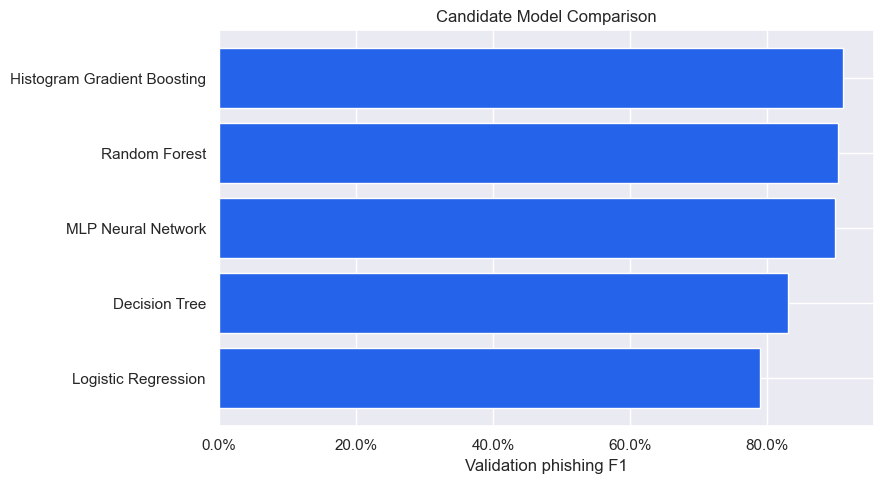

In [5]:
comparison_columns = [
    "model_name", "accuracy", "phish_precision", "phish_recall",
    "phish_f1", "weighted_f1", "roc_auc", "pr_auc",
    "false_positives", "false_negatives",
]
comparison_columns = [
    column for column in comparison_columns if column in validation_results.columns
]
comparison = validation_results[comparison_columns].sort_values(
    "phish_f1", ascending=False
).reset_index(drop=True)

display(comparison.style.format({
    "accuracy": "{:.2%}",
    "phish_precision": "{:.2%}",
    "phish_recall": "{:.2%}",
    "phish_f1": "{:.2%}",
    "weighted_f1": "{:.2%}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
}, na_rep="N/A"))

fig, ax = plt.subplots(figsize=(9, 5))
plot_data = comparison.sort_values("phish_f1")
ax.barh(plot_data["model_name"], plot_data["phish_f1"], color="#2563EB")
ax.set_xlabel("Validation phishing F1")
ax.set_title("Candidate Model Comparison")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))
plt.tight_layout()
plt.show()

In [6]:
selected_model = evaluation["model_name"]
selected_validation = validation_results.loc[
    validation_results["model_name"] == selected_model
]
if len(selected_validation) != 1:
    raise ValueError("The selected model must have exactly one validation result row.")

print(f"Selected model: {selected_model}")
print("Selection source: saved validation comparison")
display(selected_validation[comparison_columns].style.format({
    "accuracy": "{:.2%}",
    "phish_precision": "{:.2%}",
    "phish_recall": "{:.2%}",
    "phish_f1": "{:.2%}",
    "weighted_f1": "{:.2%}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
}, na_rep="N/A"))

Selected model: Histogram Gradient Boosting
Selection source: saved validation comparison


,model_name,accuracy,phish_precision,phish_recall,phish_f1,weighted_f1,roc_auc,pr_auc,false_positives,false_negatives
3,Histogram Gradient Boosting,97.32%,87.29%,95.14%,91.05%,97.37%,0.9930,0.9718,345,121


## 4. Final domain-unseen test performance

These are the saved results from the single final evaluation performed by `train_models.py`. This notebook does not call `predict` or `predict_proba`.

In [7]:
metric_labels = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "phish_precision": "Phishing precision",
    "phish_recall": "Phishing recall",
    "phish_f1": "Phishing F1",
    "weighted_f1": "Weighted F1",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "log_loss": "Log loss",
    "brier_score": "Brier score",
}

test_row = final_test_metrics.iloc[0]
metric_table = pd.DataFrame([
    {"Metric": label, "Value": test_row[key]}
    for key, label in metric_labels.items()
    if key in final_test_metrics.columns
])
display(metric_table.style.format({"Value": "{:.4f}"}))

,Metric,Value
0,Accuracy,0.9689
1,Balanced accuracy,0.9494
2,Phishing precision,0.8690
3,Phishing recall,0.9221
4,Phishing F1,0.8948
5,Weighted F1,0.9692
6,ROC-AUC,0.9918
7,PR-AUC,0.9639
8,Log loss,0.0888
9,Brier score,0.0243


## 5. Confusion matrix

False negatives are the most security-sensitive errors because they are phishing URLs classified as legitimate.

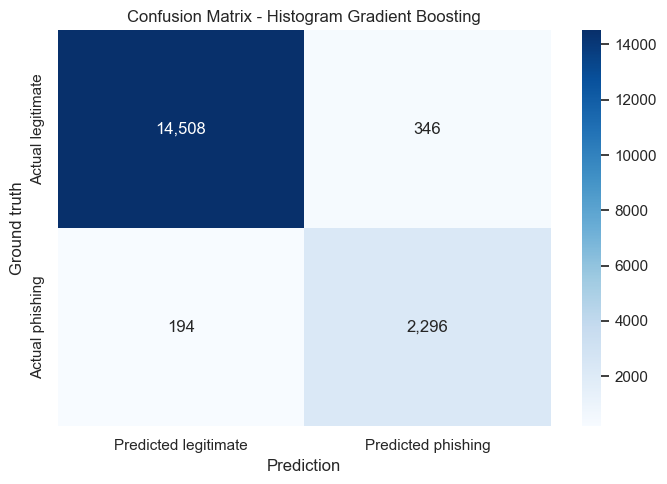

False positives: 346
False negatives: 194


In [8]:
tn = int(evaluation["true_negatives"])
fp = int(evaluation["false_positives"])
fn = int(evaluation["false_negatives"])
tp = int(evaluation["true_positives"])
confusion = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual legitimate", "Actual phishing"],
    columns=["Predicted legitimate", "Predicted phishing"],
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion, annot=True, fmt=",d", cmap="Blues", ax=ax)
ax.set_title(f"Confusion Matrix - {selected_model}")
ax.set_xlabel("Prediction")
ax.set_ylabel("Ground truth")
plt.tight_layout()
plt.show()

print(f"False positives: {fp:,}")
print(f"False negatives: {fn:,}")

## 6. ROC and precision-recall curves

The curve coordinates were saved during the official test evaluation. Plotting the saved coordinates does not access the model or test labels again.

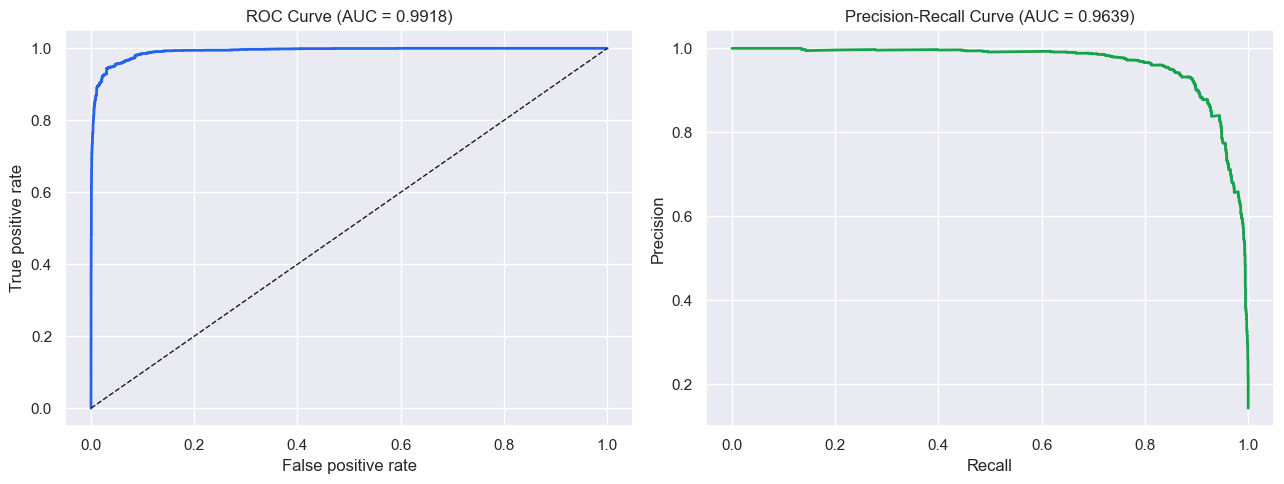

In [9]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

ax_roc.plot(test_curves["fpr"], test_curves["tpr"], color="#2563EB", linewidth=2)
ax_roc.plot([0, 1], [0, 1], "k--", linewidth=1)
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title(f"ROC Curve (AUC = {evaluation['roc_auc']:.4f})")

ax_pr.plot(
    test_curves["recall"], test_curves["precision"],
    color="#16A34A", linewidth=2,
)
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title(f"Precision-Recall Curve (AUC = {evaluation['pr_auc']:.4f})")

plt.tight_layout()
plt.show()

## 7. Permutation feature importance

The production pipeline computes permutation importance on validation data before the final refit and test evaluation. A larger mean decrease in phishing F1 indicates that the model relied more heavily on that feature.

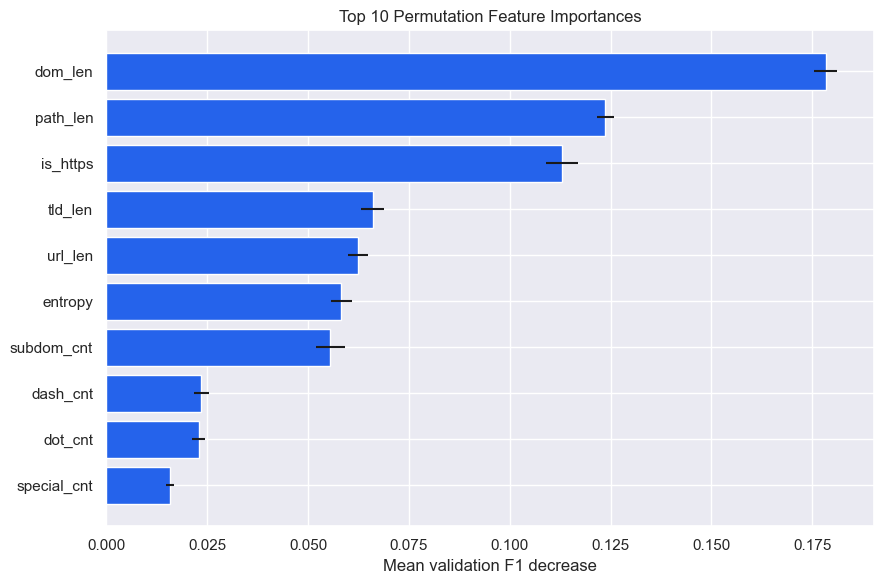

,feature,importance_mean,importance_std
0,dom_len,0.178314,0.002913
1,path_len,0.123649,0.002113
2,is_https,0.113024,0.003996
3,tld_len,0.065984,0.002829
4,url_len,0.062372,0.002527
5,entropy,0.058289,0.002518
6,subdom_cnt,0.055547,0.003498
7,dash_cnt,0.023580,0.001946
8,dot_cnt,0.022897,0.001570
9,special_cnt,0.015807,0.001004


In [10]:
importance_plot = feature_importance.sort_values(
    "importance_mean", ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    importance_plot["feature"][::-1],
    importance_plot["importance_mean"][::-1],
    xerr=importance_plot["importance_std"][::-1],
    color="#2563EB",
)
ax.set_xlabel("Mean validation F1 decrease")
ax.set_title("Top 10 Permutation Feature Importances")
plt.tight_layout()
plt.show()

display(feature_importance.head(22))

## 8. Safe test-error analysis

Only defanged and truncated URLs are displayed. The raw full-test and demonstration files remain local and are excluded from Git.

False positives in saved analysis: 346
False negatives in saved analysis: 194

Sample false positives (defanged):


,display_url,phish_probability
199,hxxps://www[.]suez-na[.]com/en-us,0.668571
353,hxxps://childrens[.]uvahealth[.]com/,0.896727
401,hxxps://www[.]asturias[.]es/portal/site/asturs...,0.992391
420,hxxps://www[.]ahcancal[.]org/Pages/Default[.]aspx,0.553630
421,hxxp://diakonhjemmetsykehus[.]no/#!/diakon/for...,0.714656
479,hxxps://ospedaledeibambini[.]it/noi-e-il-buzzi/,0.699774
497,hxxps://www[.]asturias[.]es/portal/site/asturs...,0.992391
524,hxxps://www[.]bronovo[.]nl/expats,0.659866
550,hxxps://www[.]novanthealth[.]org/forsyth-medic...,0.955619
554,hxxps://lakemedelsverket[.]se/english/,0.877126


Sample false negatives (defanged):


,display_url,phish_probability
14856,hxxps://ny[.]revepy[.]cc/us/,0.161610
14857,hxxps://ny[.]revepy[.]cc/us,0.130073
14888,hxxps://tt[.]reviewshake[.]com/,0.020913
14889,hxxps://tt[.]reviewshake[.]com/index[.]php,0.135845
14890,hxxps://ny[.]revebc[.]cc/us,0.130073
14891,hxxps://ny[.]revebc[.]cc/us/,0.176784
14892,hxxps://ae[.]goodmoreai[.]mom/,0.022956
14894,hxxps://ny[.]pqpayshr[.]cc/us/,0.459918
14909,hxxps://ar[.]serviziogoodfattyitaly[.]sbs/inde...,0.491580
14944,hxxps://www[.]infospv-be[.]com/,0.082111


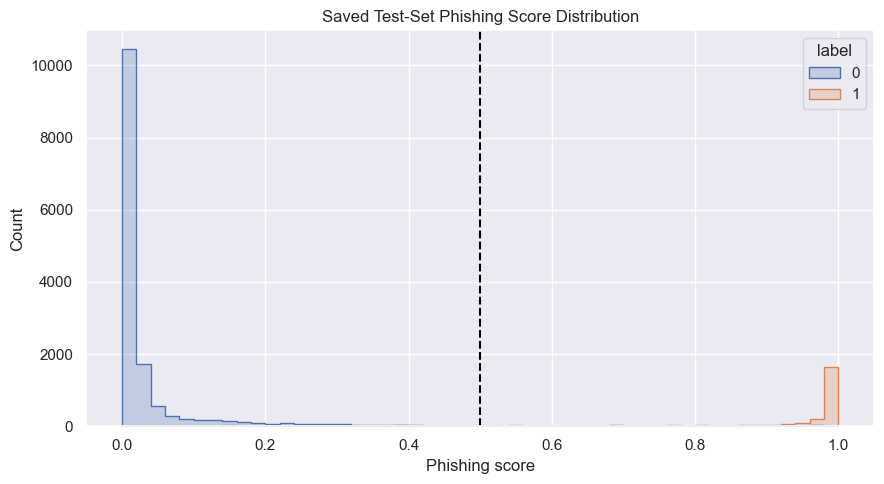

In [11]:
false_positives = test_analysis.loc[
    (test_analysis["label"] == 0) & (test_analysis["predicted_label"] == 1)
].copy()
false_negatives = test_analysis.loc[
    (test_analysis["label"] == 1) & (test_analysis["predicted_label"] == 0)
].copy()

print(f"False positives in saved analysis: {len(false_positives):,}")
print(f"False negatives in saved analysis: {len(false_negatives):,}")

safe_columns = ["display_url", "phish_probability"]
print("\nSample false positives (defanged):")
display(false_positives[safe_columns].head(10))
print("Sample false negatives (defanged):")
display(false_negatives[safe_columns].head(10))

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=test_analysis,
    x="phish_probability",
    hue="label",
    bins=50,
    element="step",
    stat="count",
    common_norm=False,
    ax=ax,
)
ax.axvline(0.5, color="black", linestyle="--", label="Decision threshold")
ax.set_title("Saved Test-Set Phishing Score Distribution")
ax.set_xlabel("Phishing score")
plt.tight_layout()
plt.show()

## 9. Deployment artifact inventory

The Streamlit application loads the four required artifacts shown below. They are produced only by the official training pipeline.

In [12]:
deployment_artifacts = [
    MODELS_DIR / "best_model.pkl",
    MODELS_DIR / "best_model_name.pkl",
    MODELS_DIR / "feature_names.pkl",
    MODELS_DIR / "best_model_evaluation.json",
]

inventory = pd.DataFrame({
    "Artifact": [str(path.relative_to(ROOT)) for path in deployment_artifacts],
    "Present": [path.exists() for path in deployment_artifacts],
    "Size (MB)": [
        round(path.stat().st_size / (1024 * 1024), 3) if path.exists() else None
        for path in deployment_artifacts
    ],
})
display(inventory)

if not inventory["Present"].all():
    raise FileNotFoundError("The complete Streamlit deployment artifact set is missing.")

,Artifact,Present,Size (MB)
0,models\best_model.pkl,True,0.702
1,models\best_model_name.pkl,True,0.000
2,models\feature_names.pkl,True,0.000
3,models\best_model_evaluation.json,True,0.001


## 10. Interpretation and limitations

- The selected model was chosen using validation phishing F1, not test performance.
- Domain-exclusive splitting gives a more realistic estimate for previously unseen domains.
- False negatives remain the most security-sensitive error type and must be discussed.
- Feature importance describes global predictive reliance; it does not prove causation for one URL.
- PhishGuard analyses URL text only. It does not visit the destination, inspect page content, or guarantee that a legitimate verdict is safe.
- Dataset labels reflect the dataset at collection time and do not prove that a URL is still active today.

In [13]:
print("Evaluation report complete.")
print(f"Selected model: {selected_model}")
print(f"Final phishing F1: {evaluation['phish_f1']:.4f}")
print(f"Final phishing recall: {evaluation['phish_recall']:.4f}")
print(f"Final ROC-AUC: {evaluation['roc_auc']:.4f}")
print("No fitting or test prediction was performed in this notebook.")

Evaluation report complete.
Selected model: Histogram Gradient Boosting
Final phishing F1: 0.8948
Final phishing recall: 0.9221
Final ROC-AUC: 0.9918
No fitting or test prediction was performed in this notebook.
